<a href="https://colab.research.google.com/github/Trap-32/ITA-Assignment/blob/main/%20Dimensionality%20Reduction%20and%20Disease%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All libraries imported successfully!

--- Step 1: Loading Data ---
Could not find 'data.csv'. Loading the built-in breast cancer dataset instead.
Data split into training and testing sets.

--- Step 2: Correlation and Normalization ---
Drawing correlation heatmap (close the image window to continue code execution)...


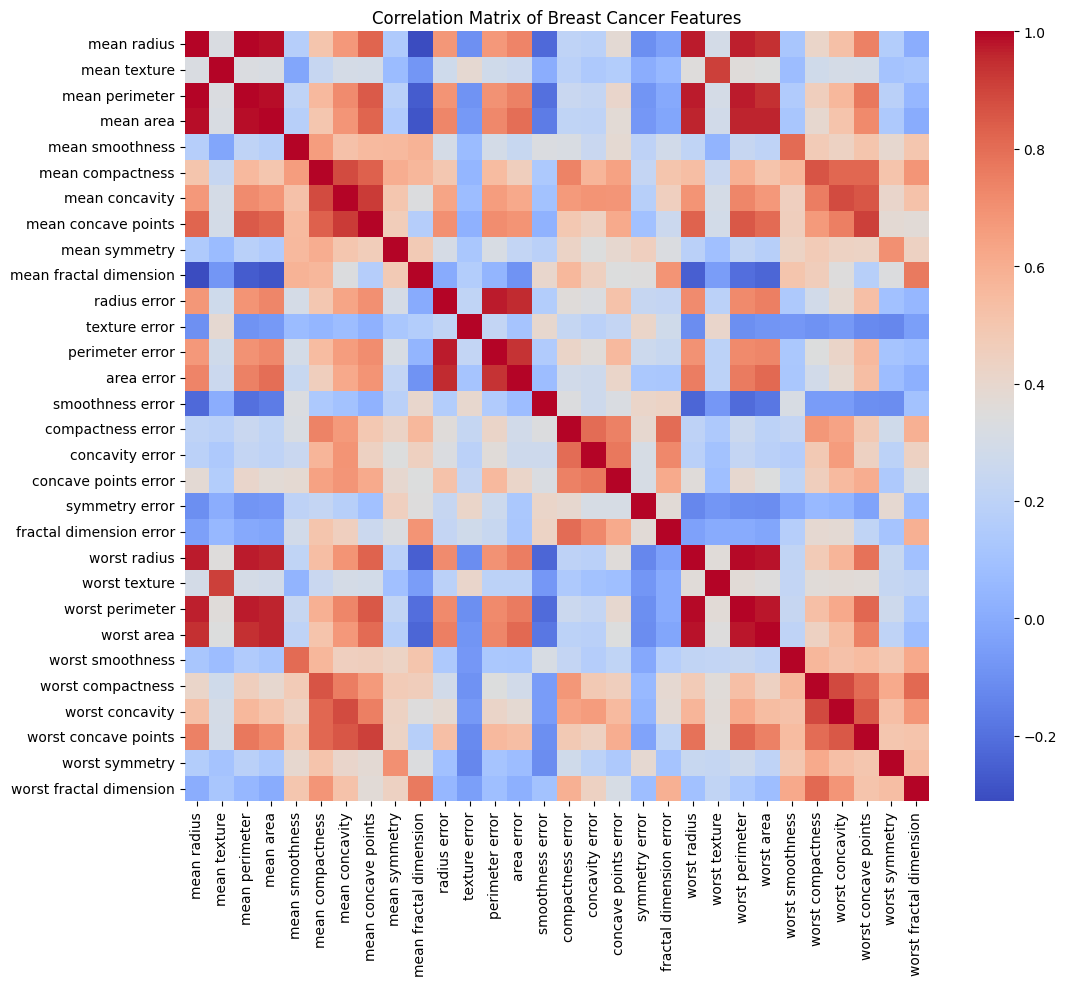

Normalizing features using StandardScaler...
Normalization complete.

--- Step 3: Applying PCA ---
Reduced data dimensions to 2 using Principal Component Analysis (PCA).

--- Step 4: Training Models ---
Testing Support Vector Machine...
Testing Logistic Regression...
Testing K-Nearest Neighbors...

--- Final Model Performance Comparison ---
            Model Name  Accuracy (All Features)  Accuracy (2 PCA Features)
Support Vector Machine                 0.976608                   0.970760
   Logistic Regression                 0.982456                   0.976608
   K-Nearest Neighbors                 0.959064                   0.947368


--- Step 5: Visualizing Decision Boundaries ---
Drawing decision boundaries (close the image window to finish)...


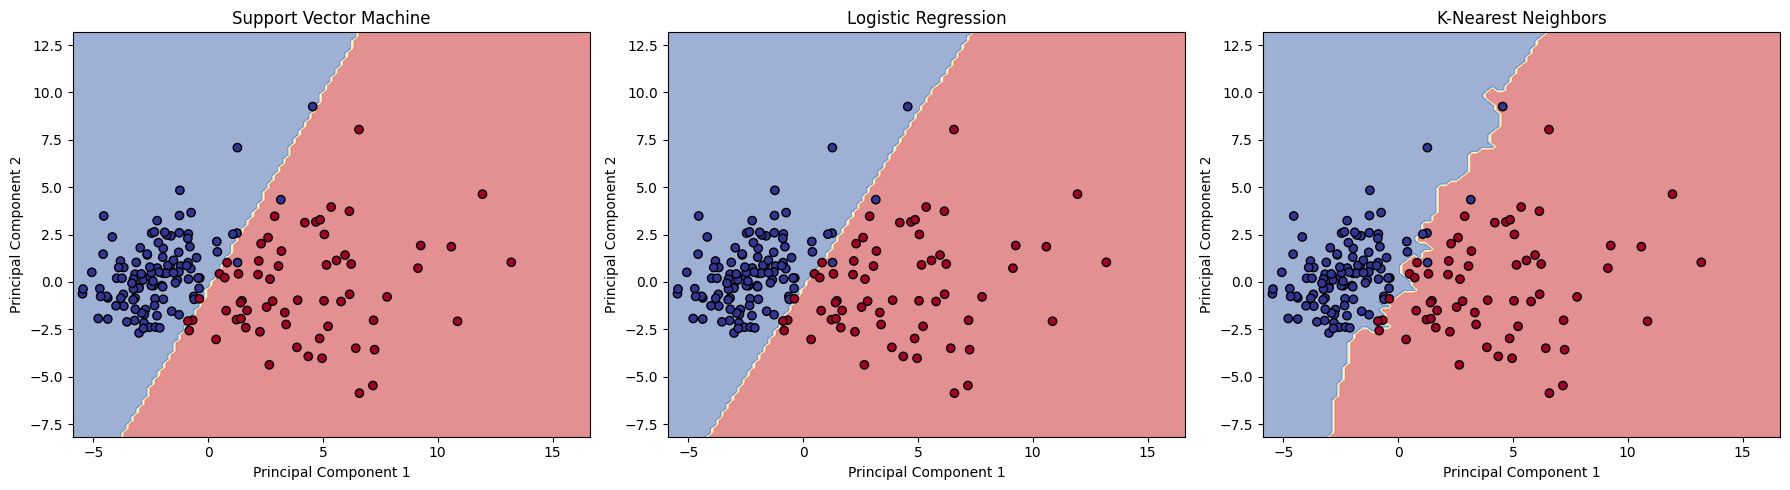

Process Complete!


In [ ]:
# =========================================================
# IMPORTING NECESSARY TOOLS
# =========================================================
# Pandas and Numpy for handling data tables and numbers
import pandas as pd
import numpy as np

# Matplotlib and Seaborn for drawing charts and graphs
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools for machine learning steps
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# The three supervised machine learning models requested
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Tools to evaluate the models and draw the boundaries
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay

print("All libraries imported successfully!\n")

# =========================================================
# STEP 1: LOAD AND CLEAN THE DATASET
# =========================================================
print("--- Step 1: Loading Data ---")

try:
    # Try to load the data from a CSV file uploaded to the environment
    df = pd.read_csv('data.csv')
    print("Successfully loaded 'data.csv'.")

    # Clean up extra columns that Kaggle sometimes adds by mistake
    if 'Unnamed: 32' in df.columns:
        df = df.drop(['Unnamed: 32'], axis=1)
        print("Removed empty 'Unnamed: 32' column.")

    if 'id' in df.columns:
        df = df.drop(['id'], axis=1)
        print("Removed 'id' column since it is not a useful feature for prediction.")

    # The 'diagnosis' column has letters 'M' (Malignant) and 'B' (Benign).
    # Machine learning models need numbers, so we change them to 1 and 0.
    y = df['diagnosis'].map({'M': 1, 'B': 0})
    X = df.drop(['diagnosis'], axis=1)

except FileNotFoundError:
    # If 'data.csv' is not found, use the built-in dataset as a backup
    print("Could not find 'data.csv'. Loading the built-in breast cancer dataset instead.")
    from sklearn.datasets import load_breast_cancer
    data = load_breast_cancer()
    X = pd.DataFrame(data.data, columns=data.feature_names)
    y = data.target

# Split the data into a training set (70%) and a testing set (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Data split into training and testing sets.\n")


# =========================================================
# STEP 2: CORRELATION ANALYSIS AND NORMALIZATION
# =========================================================
print("--- Step 2: Correlation and Normalization ---")

# 2A: Create a heatmap to see which features are highly correlated
print("Drawing correlation heatmap (close the image window to continue code execution)...")
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix of Breast Cancer Features")
plt.show()

# 2B: Normalize the features so they all have the same scale
# We only fit the scaler on the training data to prevent "cheating" (data leakage)
print("Normalizing features using StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Normalization complete.\n")


# =========================================================
# STEP 3: DIMENSIONALITY REDUCTION (PCA)
# =========================================================
print("--- Step 3: Applying PCA ---")

# We use PCA to shrink the number of features down to just 2
# This will help us plot a 2D graph later
pca = PCA(n_components=2)

# Apply PCA to both training and testing sets
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("Reduced data dimensions to 2 using Principal Component Analysis (PCA).\n")


# =========================================================
# STEP 4: TRAIN MODELS AND COMPARE PERFORMANCE
# =========================================================
print("--- Step 4: Training Models ---")

# Setup the three models we want to test
svm_model = SVC(kernel='linear', random_state=42)
log_reg_model = LogisticRegression(random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Put them in a list so we can loop through them one by one
models_to_test = [
    ("Support Vector Machine", svm_model),
    ("Logistic Regression", log_reg_model),
    ("K-Nearest Neighbors", knn_model)
]

# Create an empty list to save our test scores
performance_results = []

# Loop through each model to train and test it
for model_name, model in models_to_test:
    print(f"Testing {model_name}...")

    # --- Test 1: Using ALL scaled features ---
    model.fit(X_train_scaled, y_train) # Train the model
    predictions_full = model.predict(X_test_scaled) # Make predictions
    accuracy_full_features = accuracy_score(y_test, predictions_full) # Grade it

    # --- Test 2: Using only the 2 PCA features ---
    model.fit(X_train_pca, y_train) # Train the model on PCA data
    predictions_pca = model.predict(X_test_pca) # Make predictions on PCA data
    accuracy_pca_features = accuracy_score(y_test, predictions_pca) # Grade it

    # Save the results for this model in our list
    performance_results.append({
        "Model Name": model_name,
        "Accuracy (All Features)": accuracy_full_features,
        "Accuracy (2 PCA Features)": accuracy_pca_features
    })

# Convert our list of results into a neat Pandas table and print it
results_table = pd.DataFrame(performance_results)
print("\n--- Final Model Performance Comparison ---")
print(results_table.to_string(index=False))
print("\n")


# =========================================================
# STEP 5: VISUALIZE DECISION BOUNDARIES
# =========================================================
print("--- Step 5: Visualizing Decision Boundaries ---")
print("Drawing decision boundaries (close the image window to finish)...")

# Create a wide image with 3 side-by-side plots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loop through our models and draw them on the plots (axes)
for ax, (model_name, model) in zip(axes, models_to_test):

    # We must train the model on the 2D PCA data again so it can be drawn on a 2D plot
    model.fit(X_train_pca, y_train)

    # Draw the background colors (Decision Boundary)
    DecisionBoundaryDisplay.from_estimator(
        model,
        X_train_pca,
        response_method="predict",
        cmap=plt.cm.RdYlBu,
        alpha=0.5,
        ax=ax,
        eps=0.5
    )

    # Draw the actual test data points on top as a scatter plot
    ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap=plt.cm.RdYlBu, edgecolors='k')

    # Add titles and labels so we know what we are looking at
    ax.set_title(f"{model_name}")
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

# Adjust spacing and show the final plot
plt.tight_layout()
plt.show()
print("Process Complete!")